In [1]:
import os
import sys

# add the source directory to system path, so that relative imports work
# this fix is only for Jupyter Notebooks
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "..")))

In [2]:
import numpy as np
import pykep
import pygmo

import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

In [3]:
from common.constants import *
from orbital_mechanics.solar_system import SolarSystem

In [4]:
ss = SolarSystem()
planetx = [pl for pl in ss.bodies if pl.name == 'PlanetX'][0]
rogue1 = [pl for pl in ss.bodies if pl.name == 'Rogue1'][0]
wakonyingo = [pl for pl in ss.bodies if pl.name == 'Wakonyingo'][0]
jotunn = [pl for pl in ss.bodies if pl.name == 'Jotunn'][0]
bespin = [pl for pl in ss.bodies if pl.name == 'Bespin'][0]
beyonc = [pl for pl in ss.bodies if pl.name == 'Beyonc'][0]
hoth = [pl for pl in ss.bodies if pl.name == 'Hoth'][0]
vulcan = [pl for pl in ss.bodies if pl.name == 'Vulcan'][0]

In [35]:
udp = pykep.trajopt.mga([planetx, rogue1, wakonyingo, bespin, jotunn],
                         t0 = [50*365.25, 160*365.25],
                         tof = 50*365.25,
                         vinf = 0,
                         multi_objective=False,
                         tof_encoding='eta')

prob = pygmo.problem(udp)
print(prob)

Problem name: MGA Trajectory
	C++ class name: pybind11::object

	Global dimension:			5
	Integer dimension:			0
	Fitness dimension:			1
	Number of objectives:			1
	Equality constraints dimension:		0
	Inequality constraints dimension:	0
	Lower bounds: [18262.5, 0.001, 0.001, 0.001, 0.001]
	Upper bounds: [58440, 0.999, 0.999, 0.999, 0.999]
	Has batch fitness evaluation: false

	Has gradient: false
	User implemented gradient sparsity: false
	Has hessians: false
	User implemented hessians sparsity: false

	Fitness evaluations: 0

	Thread safety: none



In [36]:
algo = pygmo.algorithm(pygmo.sade(gen=1000))
algo.set_verbosity(10)

pop = pygmo.population(prob=prob, size=100)
pop = algo.evolve(pop)


   Gen:        Fevals:          Best:             F:            CR:            dx:            df:
      1            100        56.7937       0.362904       0.751154        19012.1        67922.8
     11           1100        38.3608       0.129559       0.542004        1182.94        209.833
     21           2100        38.3608       0.129559       0.542004        9082.32         106.79
     31           3100        38.3608       0.129559       0.542004        5615.88         93.084
     41           4100        37.9535       0.187736      0.0379509        6898.04        93.4749
     51           5100        37.8186       0.359188       0.869809        6243.25        93.3072
     61           6100        37.1009       0.654832       0.891029        1919.41        22.1167
     71           7100        36.6772       0.537128       0.451413        6518.74        22.4149
     81           8100        36.6712       0.537128       0.451413        6518.73         22.421
     91           9

In [37]:
udp.pretty(pop.champion_x)

Multiple Gravity Assist (MGA) problem: 
Planet sequence:  ['PlanetX', 'Rogue1', 'Wakonyingo', 'Bespin', 'Jotunn']
Departure:  PlanetX
	Epoch:  43777.89352880731  [mjd2000]
	Spacecraft velocity:  (16.401091484865127, 0.32604695172804465, 8.461119439764387) [m/s]
	Hyperbolic velocity:  18.817513664967123 [m/s]
	Initial DV:  18.817513664967123 [m/s]
Fly-by:  Rogue1
	Epoch:  51775.24098897053  [mjd2000]
	DV:  4.516401475029852e-09 [m/s]
Fly-by:  Wakonyingo
	Epoch:  56514.12068324156  [mjd2000]
	DV:  0.0 [m/s]
Fly-by:  Bespin
	Epoch:  61743.532372068876  [mjd2000]
	DV:  1.4305389228752574e-07 [m/s]
Arrival:  Jotunn
	Epoch:  62040.096667639125  [mjd2000]
	Spacecraft velocity:  (-13.08390050958512, -16.58984415075168, -2.711021725016715) [m/s]
	Arrival DV:  17.618312109299435 [m/s]
Time of flights:  [np.float64(7997.347460163217), np.float64(4738.879694271031), np.float64(5229.4116888273165), np.float64(296.56429557024757)] [days]


<Axes3D: >

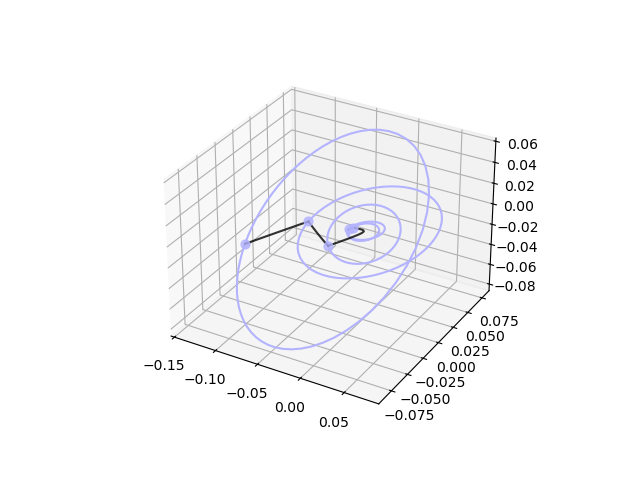

In [38]:
%matplotlib widget
udp.plot(pop.champion_x)

In [26]:
54682.63916349109/ 365.25

149.71290667622475

In [54]:
mu = 6598433.391
rp = 13531.400
murp = mu/1.1/rp

sind2 = murp/(8**2 + murp)
d2 = np.rad2deg(2*np.asin(sind2))
d2

np.float64(121.8168814471855)

In [11]:
np.linalg.norm(np.array([4.5118141001616,1.5975445285723726,1.4018571667164514]))

np.float64(4.987365889030284)